In [1]:
#Make sure R can find packages installed with Conda
.libPaths('/hb/home/jbos/.conda/envs/vcfR')
.libPaths("/hb/home/jbos/.conda/envs/vcfR/lib/R/library")

In [2]:
library(tidyverse)
library(stats)
library(cowplot)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




In [3]:
thetasB<-read.table('/scratch/jbos/Moz_aligned_mil/grp1_safs_allSNPs/finer.pestPG')

In [4]:
thetasA_north<-read.table('/scratch/jbos/Moz_aligned_mil/grp7_safs_allSNPs/finer.pestPG')

In [5]:
thetasA_south<-read.table('/scratch/jbos/Moz_aligned_mil/grp3_safs_allSNPs/finer.pestPG')

In [6]:
colnames(thetasB)<-c('first','Chr','WinCenter','tW','tP','tF','tH','tL','Tajima','fuf','fud','fayh','zeng','nSites')
colnames(thetasA_north)<-c('first','Chr','WinCenter','tW','tP','tF','tH','tL','Tajima','fuf','fud','fayh','zeng','nSites')
colnames(thetasA_south)<-c('first','Chr','WinCenter','tW','tP','tF','tH','tL','Tajima','fuf','fud','fayh','zeng','nSites')

In [7]:
#Taken from FST comparison. FST>0.3 between species A and species B
hes1_start<-20455000 - (50000/2)
hes1_end<-20525000 + (50000/2)
hes1_sel<-function(thetas){
    hes1<-thetas[thetas$Chr=='NC_058072.1',]
    hes1<-hes1[hes1$WinCenter>hes1_start,]
    hes1<-hes1[hes1$WinCenter<hes1_end,]
    return(hes1)
    }

In [8]:
#Select second gene 
gene1_start<-20450110
gene1_end<-20468842
gene1_sel<-function(thetas){
    g1<-thetas[thetas$Chr=='NC_058072.1',]
    g1<-g1[g1$WinCenter>gene1_start,]
    g1<-g1[g1$WinCenter<gene1_end,]
    return(g1)
    }

In [9]:
#Taken from FST comparison. FST>0.3 between species A and species B
gene2_start<-20495840
gene2_end<-20513836
gene2_sel<-function(thetas){
    g2<-thetas[thetas$Chr=='NC_058072.1',]
    g2<-g2[g2$WinCenter>gene2_start,]
    g2<-g2[g2$WinCenter<gene2_end,]
    return(g2)
    }

In [10]:
#Read in genes. Sort for mRNA
gff <- read.table('/home/jbos/Moz_scripts/amillepora_GCF013753865.gff', sep="\t", comment.char="#",blank.lines.skip=TRUE,quote="")
colnames(gff)<-c('chrom','V2','typeof','startpos','endpos','V6','V7','V8','V9')
gff_mRNA<-gff[gff$typeof=='mRNA',]
gff_lncRNA<-gff[gff$typeof=='lnc_RNA',]

In [11]:
#Select out HES1 region for mRNA and lncRNAs
gff7_mRNA<-gff_mRNA[gff_mRNA$chrom=='NC_058072.1',]
gff_mRNA_hes1<-gff7_mRNA[gff7_mRNA$startpos>(hes1_start-1000),]
gff_mRNA_hes1<-gff_mRNA_hes1[gff_mRNA_hes1$endpos<(hes1_end+1000),]

gff7_lncRNA<-gff_lncRNA[gff_lncRNA$chrom=='NC_058072.1',]
gff_lncRNA_hes1<-gff7_lncRNA[gff7_lncRNA$startpos>(hes1_start-1000),]
gff_lncRNA_hes1<-gff_lncRNA_hes1[gff_lncRNA_hes1$endpos<(hes1_end+1000),]

In [13]:
gff_mRNA_hes1$length <-gff_mRNA_hes1$endpos - gff_mRNA_hes1$startpos
gff_mRNA_hes1$length

[1]  3848 18732 18732 17996  5327 18739

In [14]:
gff_mRNA_hes1

,chrom,V2,typeof,startpos,endpos,V6,V7,V8,V9,length
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
395323,NC_058072.1,Gnomon,mRNA,20446163,20450011,.,+,.,"ID=rna-XM_029332097.2;Parent=gene-LOC114955278;Dbxref=GeneID:114955278,Genbank:XM_029332097.2;Name=XM_029332097.2;experiment=COORDINATES: polyA evidence [ECO:0006239];gbkey=mRNA;gene=LOC114955278;model_evidence=Supporting evidence includes similarity to: 3 mRNAs%2C 2 Proteins%2C and 100%25 coverage of the annotated genomic feature by RNAseq alignments%2C including 94 samples with support for all annotated introns;product=uncharacterized LOC114955278;transcript_id=XM_029332097.2",3848
395331,NC_058072.1,Gnomon,mRNA,20450110,20468842,.,-,.,"ID=rna-XM_029332102.2;Parent=gene-LOC114955281;Dbxref=GeneID:114955281,Genbank:XM_029332102.2;Name=XM_029332102.2;gbkey=mRNA;gene=LOC114955281;model_evidence=Supporting evidence includes similarity to: 4 mRNAs%2C 1 Protein%2C and 100%25 coverage of the annotated genomic feature by RNAseq alignments%2C including 49 samples with support for all annotated introns;product=uncharacterized LOC114955281%2C transcript variant X2;transcript_id=XM_029332102.2",18732
395340,NC_058072.1,Gnomon,mRNA,20450110,20468842,.,-,.,"ID=rna-XM_029332101.2;Parent=gene-LOC114955281;Dbxref=GeneID:114955281,Genbank:XM_029332101.2;Name=XM_029332101.2;gbkey=mRNA;gene=LOC114955281;model_evidence=Supporting evidence includes similarity to: 6 mRNAs%2C 1 Protein%2C and 100%25 coverage of the annotated genomic feature by RNAseq alignments%2C including 57 samples with support for all annotated introns;product=uncharacterized LOC114955281%2C transcript variant X1;transcript_id=XM_029332101.2",18732
395391,NC_058072.1,Gnomon,mRNA,20495840,20513836,.,+,.,"ID=rna-XM_044323458.1;Parent=gene-LOC114955285;Dbxref=GeneID:114955285,Genbank:XM_044323458.1;Name=XM_044323458.1;experiment=COORDINATES: polyA evidence [ECO:0006239];gbkey=mRNA;gene=LOC114955285;model_evidence=Supporting evidence includes similarity to: 1 Protein%2C and 91%25 coverage of the annotated genomic feature by RNAseq alignments;product=uncharacterized LOC114955285%2C transcript variant X1;transcript_id=XM_044323458.1",17996
395405,NC_058072.1,Gnomon,mRNA,20526503,20531830,.,-,.,"ID=rna-XM_029332103.2;Parent=gene-LOC114955283;Dbxref=GeneID:114955283,Genbank:XM_029332103.2;Name=XM_029332103.2;experiment=COORDINATES: polyA evidence [ECO:0006239];gbkey=mRNA;gene=LOC114955283;model_evidence=Supporting evidence includes similarity to: 5 mRNAs%2C 4 ESTs%2C 4 Proteins%2C and 100%25 coverage of the annotated genomic feature by RNAseq alignments%2C including 83 samples with support for all annotated introns;product=uncharacterized LOC114955283;transcript_id=XM_029332103.2",5327
395417,NC_058072.1,Gnomon,mRNA,20531831,20550570,.,-,.,"ID=rna-XM_044323788.1;Parent=gene-LOC114955279;Dbxref=GeneID:114955279,Genbank:XM_044323788.1;Name=XM_044323788.1;Note=The sequence of the model RefSeq transcript was modified relative to this genomic sequence to represent the inferred CDS: deleted 4 bases in 4 codons;exception=unclassified transcription discrepancy;gbkey=mRNA;gene=LOC114955279;model_evidence=Supporting evidence includes similarity to: 5 mRNAs%2C 2 Proteins%2C and 87%25 coverage of the annotated genomic feature by RNAseq alignments;product=uncharacterized LOC114955279;transcript_id=XM_044323788.1",18739


In [14]:
#Select out various regions for thetas
hes1_B<-hes1_sel(thetasB)
hes1_north<-hes1_sel(thetasA_north)
hes1_south<-hes1_sel(thetasA_south)

gene1_B<-gene1_sel(thetasB)
gene1_north<-gene1_sel(thetasA_north)
gene1_south<-gene1_sel(thetasA_south)

gene2_B<-gene2_sel(thetasB)
gene2_north<-gene2_sel(thetasA_north)
gene2_south<-gene2_sel(thetasA_south)

In [15]:
#Create CDFs for Tajima's D for each taxon
tajima_ecdf_B <- ecdf(thetasB$Tajima)
tajima_ecdf_n <- ecdf(thetasA_north$Tajima)
tajima_ecdf_s <- ecdf(thetasA_south$Tajima)

In [16]:
#Create CDFs for pi for each taxon
pi_ecdf_B <- ecdf(thetasB$tP/thetasB$nSites)
pi_ecdf_n <- ecdf(thetasA_north$tP/thetasA_north$nSites)
pi_ecdf_s <- ecdf(thetasA_south$tP/thetasA_south$nSites)

In [17]:
#Create CDFs for Watterson's Theta for each taxon
wat_ecdf_B <- ecdf(thetasB$tW/thetasB$nSites)
wat_ecdf_n <- ecdf(thetasA_north$tW/thetasA_north$nSites)
wat_ecdf_s <- ecdf(thetasA_south$tW/thetasA_south$nSites)

In [18]:
#Check Tajima's D HES1 percentile against Tajima's D CDF
tajima_ecdf_B(median(hes1_B$Tajima)) 
tajima_ecdf_n(median(hes1_north$Tajima)) 
tajima_ecdf_s(median(hes1_south$Tajima))

tajima_ecdf_B(median(gene1_B$Tajima)) 
tajima_ecdf_n(median(gene1_north$Tajima)) 
tajima_ecdf_s(median(gene1_south$Tajima)) 

tajima_ecdf_B(median(gene2_B$Tajima)) 
tajima_ecdf_n(median(gene2_north$Tajima)) 
tajima_ecdf_s(median(gene2_south$Tajima)) 

[1] 0.1181441

[1] 0.06887019

[1] 0.3720975

[1] 0.04729354

[1] 0.02745711

[1] 0.04680978

[1] 0.0502915

[1] 0.5895997

[1] 0.9472678

In [19]:
#Check Tajima's D pi percentile against pi CDF
pi_ecdf_B(median(hes1_B$tP/hes1_B$nSites,na.rm=TRUE)) 
pi_ecdf_n(median(hes1_north$tP/hes1_north$nSites,na.rm=TRUE)) 
pi_ecdf_s(median(hes1_south$tP/hes1_south$nSites,na.rm=TRUE)) 

[1] 0.02259101

[1] 0.01261246

[1] 0.1959003

In [20]:
#Check Tajima's D Watterson's theta percentile against pi CDF
wat_ecdf_B(median(hes1_B$tW/hes1_B$nSites,na.rm=TRUE)) 
wat_ecdf_n(median(hes1_north$tW/hes1_north$nSites,na.rm=TRUE)) 
wat_ecdf_s(median(hes1_south$tW/hes1_south$nSites,na.rm=TRUE)) 

[1] 0.02653

[1] 0.02317855

[1] 0.1418615

In [21]:
median(thetasB$Tajima)
median(thetasA_north$Tajima)
median(thetasA_south$Tajima)

[1] 0

[1] -0.333131

[1] -0.3873835

In [23]:
mean(thetasB$Tajima)
mean(thetasA_north$Tajima)
mean(thetasA_south$Tajima)

[1] 0.2152997

[1] -0.4261988

[1] -0.4993377

In [24]:
plt1<-ggplot(data = hes1_B, aes(x = WinCenter, y = Tajima, alpha=0.25)) +
  geom_point(size = 3,col='navyblue') +
  geom_rect(data = gff_mRNA_hes1, 
            aes(xmin = startpos, xmax = endpos, ymin = -Inf, ymax = Inf),
            inherit.aes = FALSE,
            fill = "lightblue", alpha = 0.2) +
geom_hline(yintercept = median(thetasB$Tajima))+
geom_hline(yintercept = quantile(thetasB$Tajima,probs=0.05),col='red')+
coord_cartesian(ylim = c(-3, 5))+
theme_minimal()+
theme(axis.title=element_blank(),axis.text.y = element_text(size = 14),axis.text.x = element_blank(),legend.position="none")

In [25]:
plt2<-ggplot(data = hes1_north, aes(x = WinCenter, y = Tajima, alpha=0.25)) +
  geom_point(size = 3,col='navyblue') +
  geom_rect(data = gff_mRNA_hes1, 
            aes(xmin = startpos, xmax = endpos, ymin = -Inf, ymax = Inf),
            inherit.aes = FALSE,
            fill = "lightblue", alpha = 0.2) +
geom_hline(yintercept = median(thetasA_north$Tajima))+
geom_hline(yintercept = quantile(thetasA_north$Tajima,probs=0.05),col='red')+
coord_cartesian(ylim = c(-3, 5))+
theme_minimal()+
theme(axis.title=element_blank(),axis.text.y = element_text(size = 14),axis.text.x = element_blank(),legend.position="none")

In [34]:
plt3<-ggplot(data = hes1_south, aes(x = WinCenter, y = Tajima, alpha=0.25)) +
  geom_point(size = 3,col='navyblue') +
  geom_rect(data = gff_mRNA_hes1, 
            aes(xmin = startpos, xmax = endpos, ymin = -Inf, ymax = Inf),
            inherit.aes = FALSE,
            fill = "lightblue", alpha = 0.2) +
labs(x = "Position", y= "Tajima's D") +
geom_hline(yintercept = median(thetasA_south$Tajima))+
geom_hline(yintercept = quantile(thetasA_south$Tajima,probs=0.05),col='red')+
coord_cartesian(ylim = c(-3, 5))+
theme_minimal()+
theme(axis.title.y = element_blank(),axis.text.y = element_text(size = 14),axis.text.x = element_text(size = 12),axis.title.x=element_text(size=22),legend.position="none")

In [35]:
combo <- plot_grid(
  plt1, plt2, plt3,
  ncol   = 1,
  nrow   = 3,
  labels = c("A)", "B)", "C)"),
  label_size = 22,
  align  = "v",
  axis   = "lr"
)
final<-ggdraw() +
  draw_plot(combo, x = 0.04, y = 0, width = 0.96, height = 1) +
  draw_label("Tajima's D", x = 0.02, y = 0.5, angle = 90, size = 22)

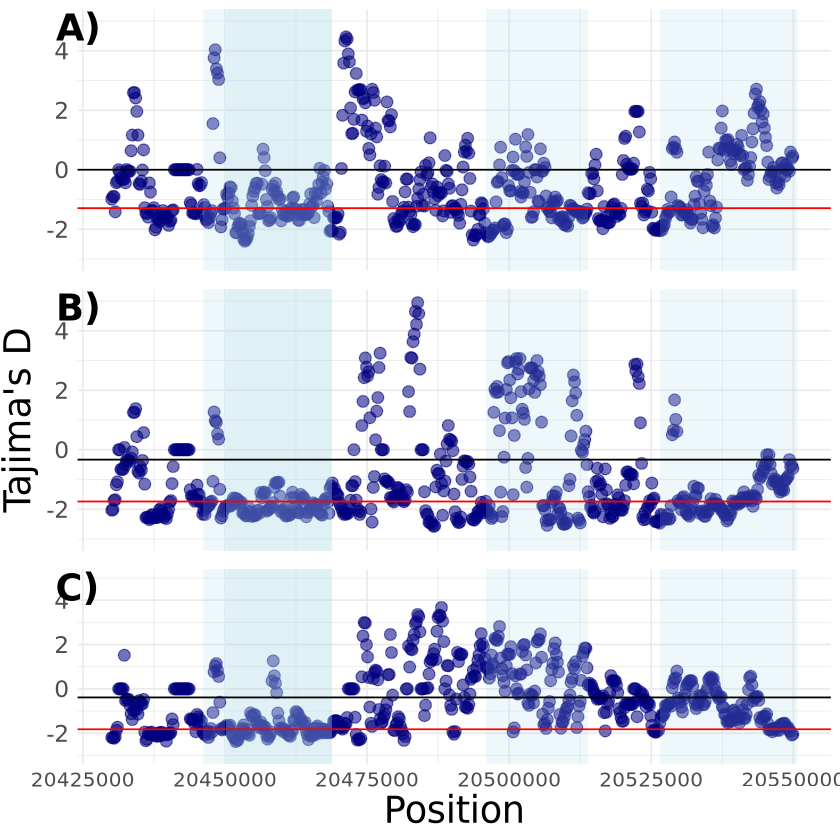

In [36]:
show(final)

In [38]:
ggsave("Acropora_Moz_fig4.png", final, width = 8, height = 12,dpi=800)